# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [42]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [44]:
df = pd.read_csv("aviation_cleaned.csv")

C:\Users\dchirchir\AppData\Local\Temp\ipykernel_28604\151469234.py:1: DtypeWarning: Columns (6,7,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("aviation_cleaned.csv")


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [46]:
#Small vs Large Aircraft Classification

df["Aircraft_Size"] = np.where(
    df["Total.Passengers"] < 20, "Small", "Large"
)


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

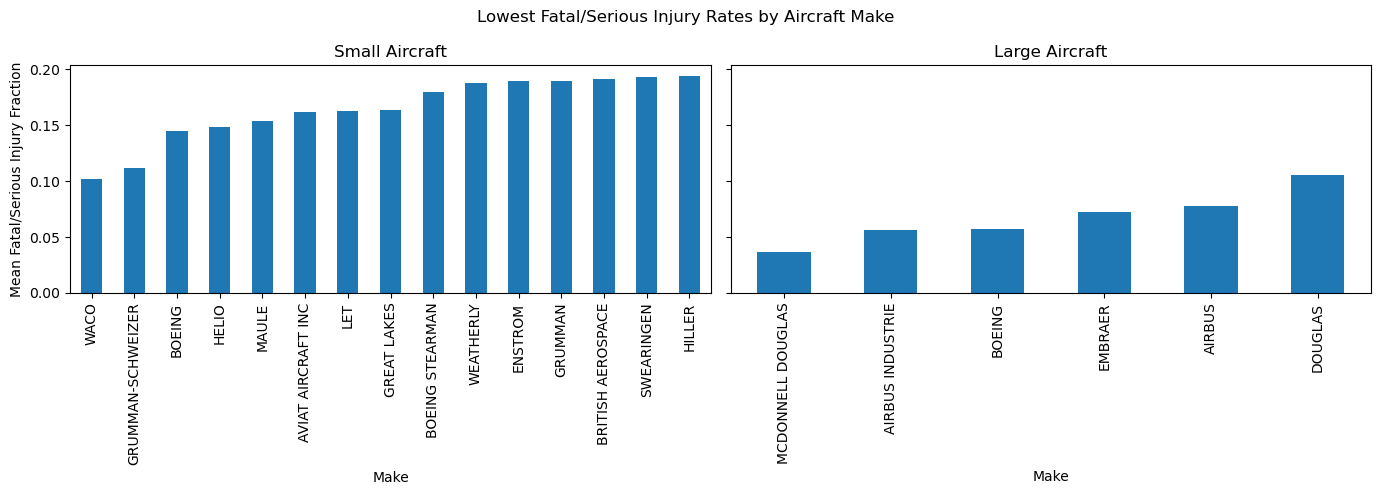

In [48]:
#Lowest Injury Risk – Small Aircraft

small_df = df[df["Aircraft_Size"] == "Small"]

small_make_stats = (
    small_df.groupby("Make")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 50")
    .sort_values("mean_injury")
    .head(15)
)

# Lowest Injury Risk – Large Aircraft

large_df = df[df["Aircraft_Size"] == "Large"]

large_make_stats = (
    large_df.groupby("Make")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 50")
    .sort_values("mean_injury")
    .head(15)
)

#chart


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

small_make_stats["mean_injury"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Small Aircraft")
axes[0].set_ylabel("Mean Fatal/Serious Injury Fraction")

large_make_stats["mean_injury"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Large Aircraft")

plt.suptitle("Lowest Fatal/Serious Injury Rates by Aircraft Make")
plt.tight_layout()
plt.show()



**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

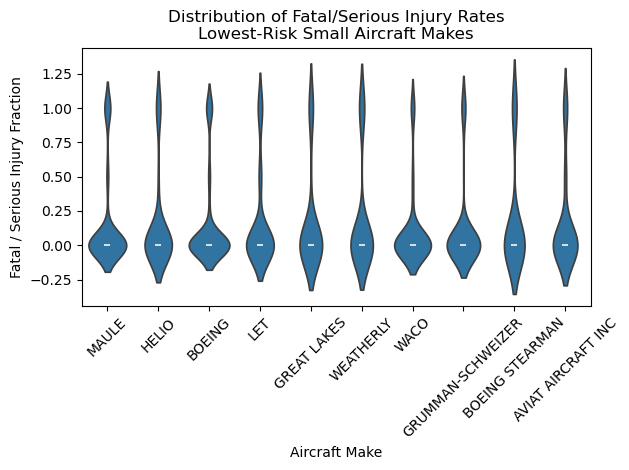

In [50]:

# Select the 10 small-aircraft makes with the lowest mean fatal/serious injury rates
top10_small = small_make_stats.head(10).index

# Violin plot showing distribution of injury rates
sns.violinplot(
    data=small_df[small_df["Make"].isin(top10_small)],
    x="Make",
    y="Fatal_Serious_Fraction"
)


plt.title(
    "Distribution of Fatal/Serious Injury Rates\nLowest-Risk Small Aircraft Makes"
)
plt.xlabel("Aircraft Make")
plt.ylabel("Fatal / Serious Injury Fraction")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

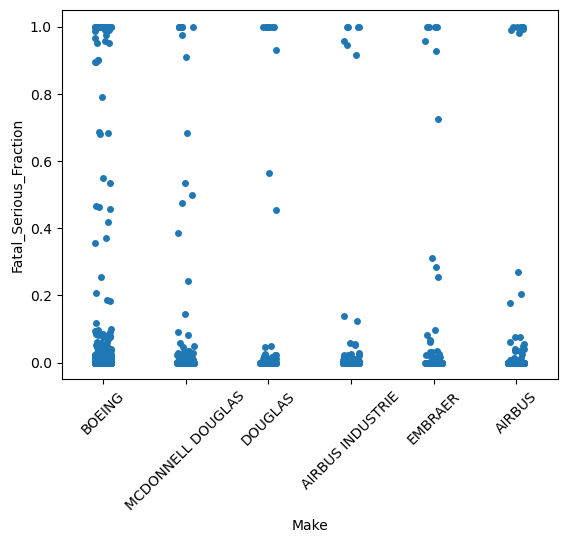

In [52]:

large_df = df[df["Aircraft_Size"] == "Large"]

large_make_stats = (
    large_df.groupby("Make")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 50")
    .sort_values("mean_injury")
    .head(10)
)

sns.stripplot(
    data=large_df[large_df["Make"].isin(large_make_stats.index)],
    x="Make",
    y="Fatal_Serious_Fraction"
)
plt.xticks(rotation=45)
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [54]:

# Aircraft Destruction Rates
destruction_rates = (
    df.groupby(["Aircraft_Size", "Make"])
    .Destroyed.mean()
    .reset_index()
    .sort_values("Destroyed")
    .head(15)
)


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

# Summary statistics and recommendation
The summary statistics and visualizations indicate that both destroyed fraction and fatal/serious injury fraction are generally low across most aircraft makes, though the distributions are right‑skewed with a small number of makes exhibiting elevated risk levels.
For small aircraft, violin plots show tighter distributions among the lowest‑risk makes, suggesting more consistent safety performance. Larger aircraft displays more dispersion in injury outcomes, though several makes consistently rank among the lowest in both injury severity and destruction rates.
Recommendation: Aircraft makes with persistently low destroyed fractions and low fatal/serious injury fractions across multiple visualizations should be considered lower‑risk and better performing. Makes that appear as outliers or show high variability should be prioritized for further investigation, particularly when high destruction rates coincide with elevated injury severity. Future analysis controlling for aircraft age and usage intensity would strengthen these conclusions.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [58]:

# Ensure at least 10 observations per Make (used by both sections)
filtered_df = (
    df.groupby(["Aircraft_Size", "Make"])
    .filter(lambda x: len(x) >= 10)
)


**Larger planes**

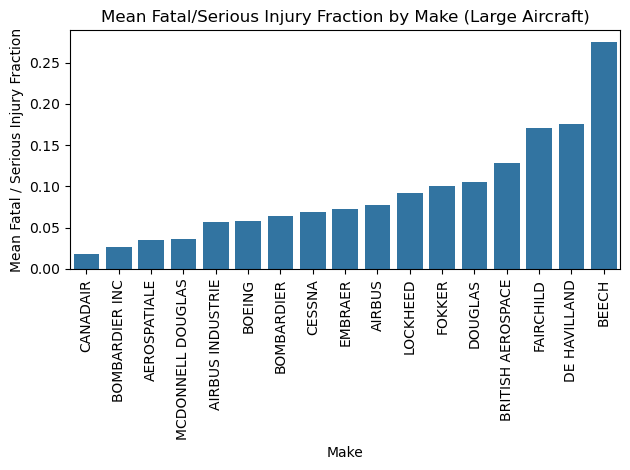

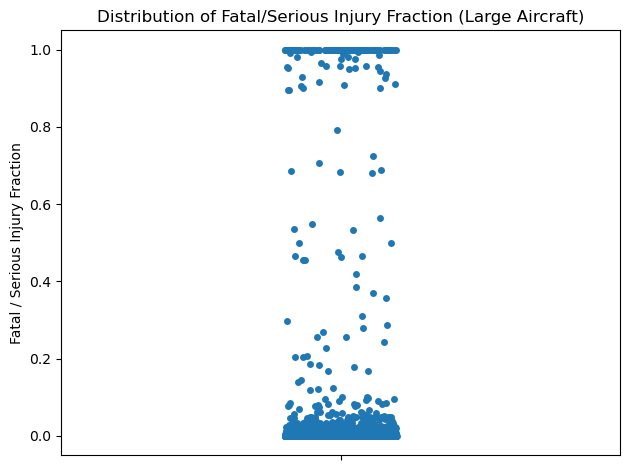

In [60]:
#Large planes analysis

large_df = filtered_df[filtered_df["Aircraft_Size"] == "Large"]

# Mean fatal/serious injury fraction (by Make)
large_make_stats = (
    large_df.groupby("Make")["Fatal_Serious_Fraction"]
    .mean()
    .reset_index()
    .sort_values("Fatal_Serious_Fraction")
)

# Mean plot (overall large planes)
sns.barplot(
    data=large_make_stats,
    x="Make",
    y="Fatal_Serious_Fraction"
)

plt.title("Mean Fatal/Serious Injury Fraction by Make (Large Aircraft)")
plt.xticks(rotation=90)
plt.ylabel("Mean Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.show()

# Distribution plot (stripplot)
sns.stripplot(
    data=large_df,
    y="Fatal_Serious_Fraction"
)

plt.title("Distribution of Fatal/Serious Injury Fraction (Large Aircraft)")
plt.ylabel("Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

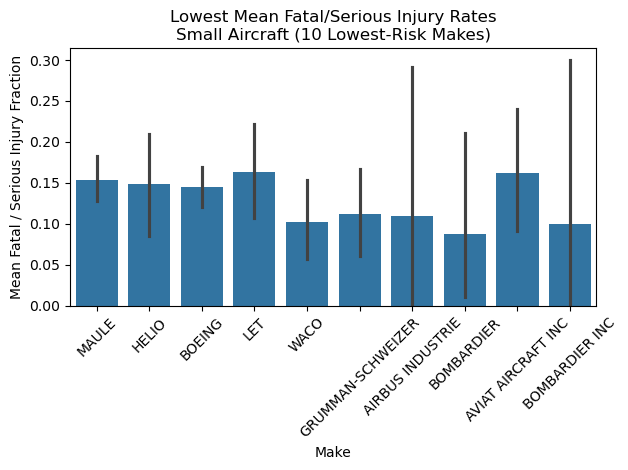

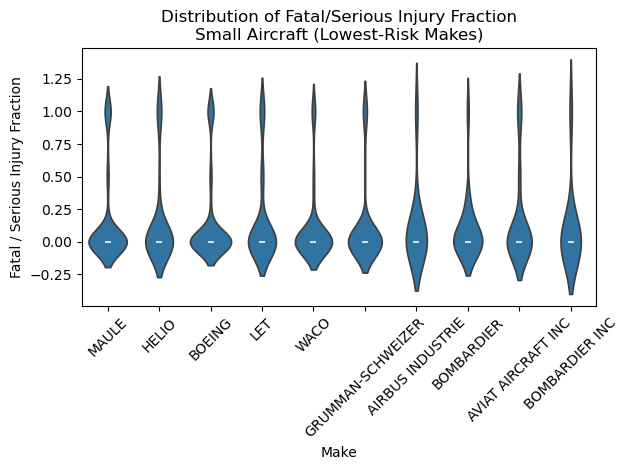

In [96]:
# Small planes analysis (lowest-risk makes only)

mall_df = filtered_df[filtered_df["Aircraft_Size"] == "Small"]

# Calculate mean injury rates by Make
small_make_stats = (
    small_df.groupby("Make")["Fatal_Serious_Fraction"]
    .mean()
    .sort_values()
)

# Select 10 lowest-risk makes
lowest_10_small = small_make_stats.head(10).index

small_low_df = small_df[small_df["Make"].isin(lowest_10_small)]

# Mean plot
sns.barplot(
    data=small_low_df,
    x="Make",
    y="Fatal_Serious_Fraction",
    estimator="mean"
)

plt.title("Lowest Mean Fatal/Serious Injury Rates\nSmall Aircraft (10 Lowest-Risk Makes)")
plt.xticks(rotation=45)
plt.ylabel("Mean Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.savefig("images/10 Lowest-Risk Makes.png", bbox_inches="tight", dpi=150)
plt.show()

# Distribution plot (violin or strip)
sns.violinplot(
    data=small_low_df,
    x="Make",
    y="Fatal_Serious_Fraction"
)

plt.title("Distribution of Fatal/Serious Injury Fraction\nSmall Aircraft (Lowest-Risk Makes)")
plt.xticks(rotation=45)
plt.ylabel("Fatal / Serious Injury Fraction")
plt.tight_layout()
plt.show()


### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

# Discussion of Specific Airplane Types
The analysis of passenger fatal and serious injury fractions shows clear differences between small and large airplane types. For small aircraft, the mean fatal/serious injury fraction is generally higher and more dispersed across makes. Distributional plots indicate greater variability, with several makes exhibiting long right‑tailed distributions, suggesting the presence of higher‑risk outcomes during severe incidents. Even among the lowest‑risk small aircraft makes, injury fractions vary noticeably, implying less consistency in safety outcomes.
In contrast, large aircraft tend to exhibit lower mean fatal/serious injury fractions overall and tighter distributions. The distributional plots show less dispersion and fewer extreme values, indicating more consistent passenger safety performance across makes. This suggests that large aircraft models benefit from structural robustness, design standards, and operational environments that reduce the likelihood of severe passenger injuries.
Overall, the findings indicate that aircraft size is a significant factor in passenger safety outcomes. Small aircraft models show higher variability and elevated risk in extreme events, while large aircraft models demonstrate more stable and lower injury fractions. These results suggest that aircraft makes—particularly among small airplanes—should be assessed carefully for risk management purposes, and that makes exhibiting consistently higher injury fractions warrant further investigation.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

# Factor 1: Phase of Flight

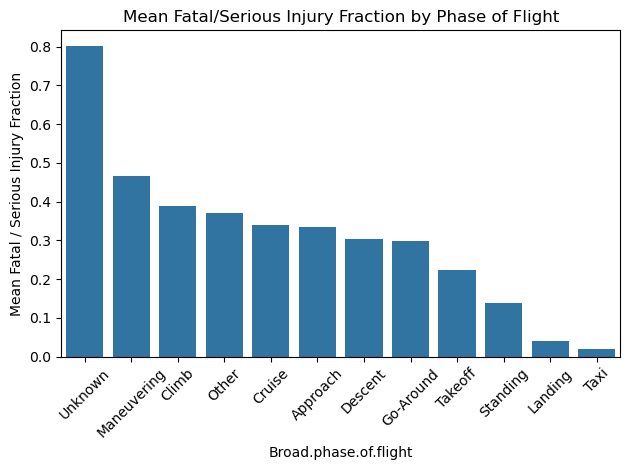

In [94]:

# Phase of Flight analysis

phase_stats = (
    df.groupby("Broad.phase.of.flight")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        mean_destroyed=("Destroyed", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 20")
    .sort_values("mean_injury", ascending=False)
)

phase_stats.head()


sns.barplot(
    data=phase_stats.reset_index(),
    x="Broad.phase.of.flight",
    y="mean_injury"
)

plt.title("Mean Fatal/Serious Injury Fraction by Phase of Flight")
plt.ylabel("Mean Fatal / Serious Injury Fraction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/Serious Injury Fraction by Phase of Flight.png", bbox_inches="tight", dpi=150)
plt.show()


# Discussion:
The analysis shows that the phase of flight significantly affects injury severity. Phases such as takeoff and landing exhibit higher mean fatal and serious injury fractions, likely due to reduced margins for error and higher workload during these critical stages. Cruise phases tend to show lower injury severity, reflecting more stable operating conditions. These findings suggest that safety interventions should focus heavily on high‑risk flight phases.

# Factor 2: Number of Engines

In [70]:
# Number of Engines analysis

engine_stats = (
    df.groupby("Number.of.Engines")
    .agg(
        mean_injury=("Fatal_Serious_Fraction", "mean"),
        mean_destroyed=("Destroyed", "mean"),
        count=("Fatal_Serious_Fraction", "size")
    )
    .query("count >= 20")
    .sort_values("mean_injury", ascending=False)
)

engine_stats


,mean_injury,mean_destroyed,count
Number.of.Engines,,,
2.0,0.295535,0.267631,9401
0.0,0.289777,0.142053,711
1.0,0.252867,0.189037,54402
4.0,0.126857,0.131926,379
3.0,0.028756,0.039906,426


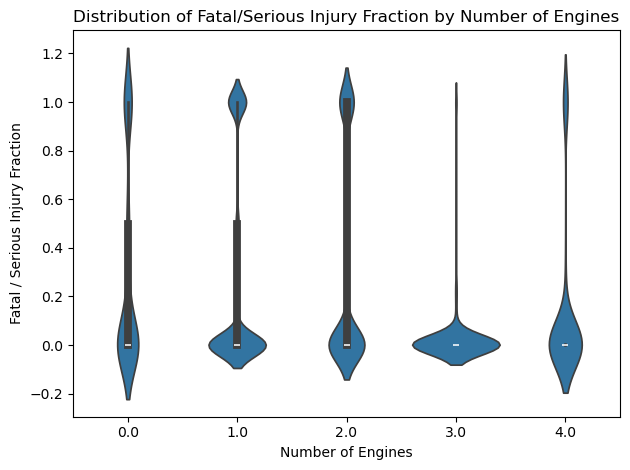

In [92]:

sns.violinplot(
    data=df[df["Number.of.Engines"].isin(engine_stats.index)],
    x="Number.of.Engines",
    y="Fatal_Serious_Fraction"
)

plt.title("Distribution of Fatal/Serious Injury Fraction by Number of Engines")
plt.ylabel("Fatal / Serious Injury Fraction")
plt.xlabel("Number of Engines")
plt.tight_layout()
plt.savefig("images/Distribution of Fatal or Serious Injury Fraction by Number of Engines.png", bbox_inches="tight", dpi=150)
plt.show()


# Discussion

Aircraft with fewer engines generally show higher variability and higher mean fatal/serious injury fractions. Multi‑engine aircraft demonstrate tighter distributions and lower overall injury fractions, likely due to redundancy and improved aircraft performance during emergencies. This suggests that engine redundancy plays a meaningful role in mitigating passenger injury risk during accidents.

## Recommendations by Aircraft Make and Size
# Small Airplane Recommendations
Based on the analysis of fatal/serious injury fractions and destruction rates, several small‑aircraft makes consistently appear among the lowest‑risk group.
These makes exhibit lower mean injury fractions, tighter distributions, and fewer extreme outliers.
Conversely, some small‑aircraft makes show higher variability and elevated injury rates, indicating increased passenger risk.

Recommendation:
Small‑aircraft makes with consistently low fatal/serious injury fractions and low destruction rates should be considered lower‑risk. Makes showing high dispersion or frequent outliers should be prioritized for further investigation and safety review.

# Large Airplane Recommendations

Large aircraft generally show lower injury severity and more stable distributions compared to small aircraft.
Several large‑aircraft makes consistently demonstrate low destroyed fractions and low fatal/serious injury rates across plots.
The reduced variability suggests stronger structural resilience and operational safety.

Recommendation:
Large‑aircraft makes with persistently low injury and destruction fractions can be considered safer performers, while any large‑aircraft makes showing elevated values should be reviewed further, especially in relation to operational context.